In [18]:
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots
from utils import safe_open_json

# Configuration
graph_names = ["mag", "prime", "amazon"]
split = "test"
model_name = "graph_explorer_gpt-4.1"
figures_dir = Path("../data/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Plotting style configuration
plt.style.use(['science', 'notebook'])
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = "Arial"

In [19]:
def count_tool_calls_per_tool(message_history):
    """Count the number of calls for each tool in the message history.
    
    Args:
        message_history: List of messages from a trajectory
        
    Returns:
        Dictionary mapping tool names to call counts
    """
    tool_counts = Counter()
    for message in message_history:
        if message.get("role") == "assistant" and "tool_calls" in message:
            for tool_call in message["tool_calls"]:
                if "function" in tool_call and "name" in tool_call["function"]:
                    tool_name = tool_call["function"]["name"]
                    tool_counts[tool_name] += 1
    return dict(tool_counts)


def calculate_metrics(retrieved_nodes, ground_truth_nodes):
    """Calculate hit@5 and recall@20 metrics.
    
    Args:
        retrieved_nodes: List of nodes retrieved by the agent
        ground_truth_nodes: List of ground truth answer nodes
        
    Returns:
        Dictionary with 'hit_at_5' (bool) and 'recall_at_20' (float)
    """
    ground_truth_set = set(ground_truth_nodes)
    
    # Hit@5: Check if any of the top 5 retrieved nodes are in ground truth
    hit_at_5 = bool(set(retrieved_nodes[:5]).intersection(ground_truth_set))
    
    # Recall@20: Fraction of ground truth nodes found in top 20 retrieved nodes
    recall_at_20 = (
        len(set(retrieved_nodes[:20]).intersection(ground_truth_set)) / len(ground_truth_set)
        if len(ground_truth_set) > 0 else 0.0
    )
    
    return {"hit_at_5": hit_at_5, "recall_at_20": recall_at_20}


def load_trajectory_data(graph_name, model_name, split):
    """Load and process trajectory data for a given graph.
    
    Args:
        graph_name: Name of the graph dataset
        model_name: Name of the model
        split: Data split (e.g., 'test')
        
    Returns:
        DataFrame with columns: hit_at_5, recall_at_20, and number_of_tool_calls_* for each tool
    """
    data_dir = Path(f"../data/experiments/{graph_name}/{model_name}/{split}")
    log_files = sorted(data_dir.glob("*.json"), key=lambda f: f.stat().st_ctime)
    logs = [safe_open_json(f) for f in log_files]
    
    rows = []
    for log in logs:
        trajectory = log["trajectories"][0]
        retrieved_nodes = trajectory["agent_answer_indices"]
        ground_truth_nodes = log["answer_indices"]
        message_history = trajectory["message_history"]
        
        # Calculate metrics
        metrics = calculate_metrics(retrieved_nodes, ground_truth_nodes)
        
        # Count tool calls
        tool_call_counts = count_tool_calls_per_tool(message_history)
        
        # Build row
        row = metrics.copy()
        for tool_name, count in tool_call_counts.items():
            row[f"number_of_tool_calls_{tool_name}"] = count
        
        rows.append(row)
    
    df = pd.DataFrame(rows).fillna(0)
    return df


# Load data for all graphs
all_data = {}
for graph_name in graph_names:
    df = load_trajectory_data(graph_name, model_name, split)
    all_data[graph_name] = df
    print(f"{graph_name.upper()}: {df.shape[0]} samples")

MAG: 2501 samples
PRIME: 2662 samples
AMAZON: 1632 samples


In [20]:
# Configuration for neighborhood exploration tool analysis
NEIGHBORHOOD_TOOL_NAME = "search_in_neighborhood"
neighborhood_tool_col = f"number_of_tool_calls_{NEIGHBORHOOD_TOOL_NAME}"

# Print summary statistics for each graph
print("=" * 60)
print("Dataset Summary")
print("=" * 60)
for graph_name, df in all_data.items():
    print(f"\n{graph_name.upper()}:")
    print(f"  Total trajectories: {df.shape[0]}")
    print(f"  Features: {df.shape[1]}")
    print(f"  Hit@5 success rate: {df['hit_at_5'].sum() / len(df):.2%}")
    print(f"  Hit@5 distribution:")
    print(f"    {df['hit_at_5'].value_counts().to_dict()}")


Dataset Summary

MAG:
  Total trajectories: 2501
  Features: 6
  Hit@5 success rate: 82.49%
  Hit@5 distribution:
    {True: 2063, False: 438}

PRIME:
  Total trajectories: 2662
  Features: 6
  Hit@5 success rate: 61.98%
  Hit@5 distribution:
    {True: 1650, False: 1012}

AMAZON:
  Total trajectories: 1632
  Features: 6
  Hit@5 success rate: 73.90%
  Hit@5 distribution:
    {True: 1206, False: 426}


Saved: ../data/figures/fig-5-neighborhood_exploration_tool_calls_distribution.pdf


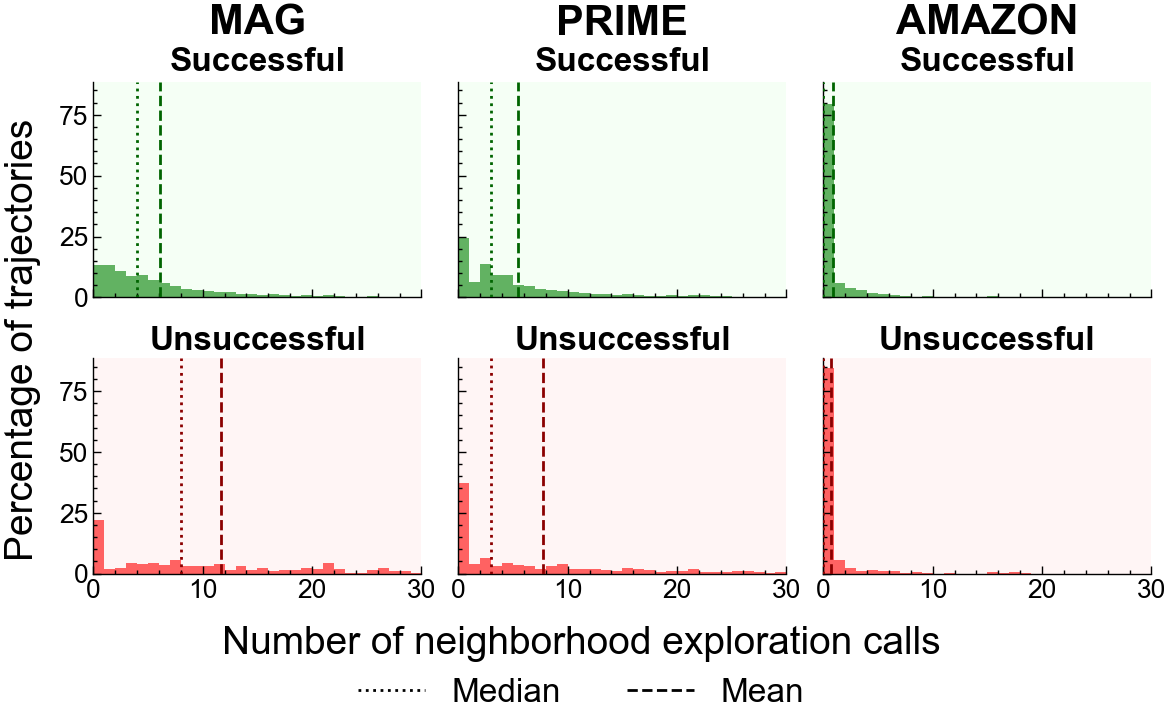

In [21]:
# ---- Font size and style constants (for plots) ----
TITLE_FONT_SIZE = 26 + 4
SUBTITLE_FONT_SIZE = 20 + 4
AXIS_LABEL_FONT_SIZE = 28
LEGEND_FONT_SIZE = 24
TICK_LABEL_FONT_SIZE = 19  # Bigger tick labels
FONT_ARIAL = "Arial"
AXIS_TITLE_PAD = 30 + 4

def plot_tool_call_distributions(
    data_dict, tool_col, tool_display_name, max_value=30, figsize=(12, 7)
):
    """Plot tool call distributions for successful vs unsuccessful trajectories.

    Args:
        data_dict: Dictionary mapping graph names to DataFrames
        tool_col: Column name for the tool call counts
        tool_display_name: Display name for the tool (for axis labels)
        max_value: Maximum x-axis value (to ignore outliers)
        figsize: Figure size tuple
    """
    graph_names = list(data_dict.keys())
    n_graphs = len(graph_names)

    fig, axes = plt.subplots(2, n_graphs, figsize=figsize, sharex=True, sharey=True)
    if n_graphs == 1:
        axes = axes.reshape(-1, 1)

    bins = range(max_value + 2)

    for idx, graph_name in enumerate(graph_names):
        df = data_dict[graph_name]

        # Split data by success
        successful = df[df["hit_at_5"] == True][tool_col].values
        unsuccessful = df[df["hit_at_5"] == False][tool_col].values

        # Plot successful trajectories (top row)
        ax_success = axes[0, idx]
        if len(successful) > 0:
            weights = np.ones(len(successful)) / len(successful) * 100
            ax_success.hist(
                successful, bins=bins, alpha=0.6, color="green", weights=weights, density=False
            )

            mean_val = successful.mean()
            median_val = np.median(successful)
            # Only show mean and median lines within axis limits
            if mean_val <= max_value:
                ax_success.axvline(
                    mean_val, color="darkgreen", linestyle="--", linewidth=2, label="Mean", zorder=10
                )
            if median_val <= max_value:
                ax_success.axvline(
                    median_val, color="darkgreen", linestyle=":", linewidth=2, label="Median", zorder=11
                )

        ax_success.set_title(
            graph_name.upper(),
            fontsize=TITLE_FONT_SIZE,
            fontweight="bold",
            fontname=FONT_ARIAL,
            pad=AXIS_TITLE_PAD,
        )
        ax_success.text(
            0.5,
            1.02,
            "Successful",
            transform=ax_success.transAxes,
            ha="center",
            va="bottom",
            fontsize=SUBTITLE_FONT_SIZE,
            fontweight="bold",
            fontname=FONT_ARIAL,
        )

        # Remove grid, ticks, spines for top and right
        ax_success.set_xlim(0, max_value)
        ax_success.set_facecolor("#f5fff5")
        ax_success.tick_params(
            top=False, right=False, labelsize=TICK_LABEL_FONT_SIZE, labelcolor="black"
        )
        ax_success.spines["top"].set_visible(False)
        ax_success.spines["right"].set_visible(False)

        # Remove top and right ticks
        ax_success.xaxis.set_tick_params(which='both', top=False)
        ax_success.yaxis.set_tick_params(which='both', right=False)

        # Make sure tick labels are bigger (in case set after above)
        for label in ax_success.get_xticklabels():
            label.set_fontsize(TICK_LABEL_FONT_SIZE)
            label.set_fontname(FONT_ARIAL)
        for label in ax_success.get_yticklabels():
            label.set_fontsize(TICK_LABEL_FONT_SIZE)
            label.set_fontname(FONT_ARIAL)

        # Plot unsuccessful trajectories (bottom row)
        ax_fail = axes[1, idx]
        if len(unsuccessful) > 0:
            weights = np.ones(len(unsuccessful)) / len(unsuccessful) * 100
            ax_fail.hist(
                unsuccessful, bins=bins, alpha=0.6, color="red", weights=weights, density=False
            )

            mean_val = unsuccessful.mean()
            median_val = np.median(unsuccessful)
            # Only show mean and median lines within axis limits
            if mean_val <= max_value:
                ax_fail.axvline(mean_val, color="darkred", linestyle="--", linewidth=2, zorder=10)
            if median_val <= max_value:
                ax_fail.axvline(median_val, color="darkred", linestyle=":", linewidth=2, zorder=11)

        ax_fail.set_title(
            "Unsuccessful",
            fontsize=SUBTITLE_FONT_SIZE,
            fontweight="bold",
            fontname=FONT_ARIAL,
        )

        # Remove grid, ticks, spines for top and right
        ax_fail.set_xlim(0, max_value)
        ax_fail.set_facecolor("#fff5f5")
        ax_fail.tick_params(
            top=False, right=False, labelsize=TICK_LABEL_FONT_SIZE, labelcolor="black"
        )
        ax_fail.spines["top"].set_visible(False)
        ax_fail.spines["right"].set_visible(False)
        # Remove top and right ticks
        ax_fail.xaxis.set_tick_params(which='both', top=False)
        ax_fail.yaxis.set_tick_params(which='both', right=False)

        # Make sure tick labels are bigger (in case set after above)
        for label in ax_fail.get_xticklabels():
            label.set_fontsize(TICK_LABEL_FONT_SIZE)
            label.set_fontname(FONT_ARIAL)
        for label in ax_fail.get_yticklabels():
            label.set_fontsize(TICK_LABEL_FONT_SIZE)
            label.set_fontname(FONT_ARIAL)

    # Add shared labels
    fig.supxlabel(
        "Number of neighborhood exploration calls",
        fontsize=AXIS_LABEL_FONT_SIZE,
        fontname=FONT_ARIAL,
        y=0.04,
    )
    fig.supylabel(
        "Percentage of trajectories",
        fontsize=AXIS_LABEL_FONT_SIZE,
        fontname=FONT_ARIAL,
    )

    # Add legend
    legend_elements = [
        Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="Median"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Mean"),
    ]
    leg = fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.06),  # Increased y for less space below legend
        ncol=2,
        # fontsize=LEGEND_FONT_SIZE,
        framealpha=0.9,
        prop={"family": FONT_ARIAL, "size": LEGEND_FONT_SIZE},
    )
    # Remove top and right frame from legend as well
    leg.get_frame().set_linewidth(0)
    leg.get_frame().set_edgecolor('none')

    plt.tight_layout(h_pad=1, rect=[0.01, 0.03, 1, 1])  # [left, bottom, right, top]
    return fig


# Plot neighborhood exploration tool call distributions
fig = plot_tool_call_distributions(
    all_data, neighborhood_tool_col, "Neighborhood Exploration", max_value=30
)

# Save figure
filename = "fig-5-neighborhood_exploration_tool_calls_distribution.pdf"
filepath = figures_dir / filename
fig.savefig(filepath, dpi=300, bbox_inches="tight", format="pdf")
print(f"Saved: {filepath}")

plt.show()

Saved: ../data/figures/fig-3-tool_call_proportions.pdf

Tool Call Proportions (All Trajectories):

AMAZON:
  Search in Graph: 87.73%
  Search in Neighborhood: 12.27%
  Total trajectories: 1632

MAG:
  Search in Graph: 34.66%
  Search in Neighborhood: 65.34%
  Total trajectories: 2501

PRIME:
  Search in Graph: 47.71%
  Search in Neighborhood: 52.29%
  Total trajectories: 2662


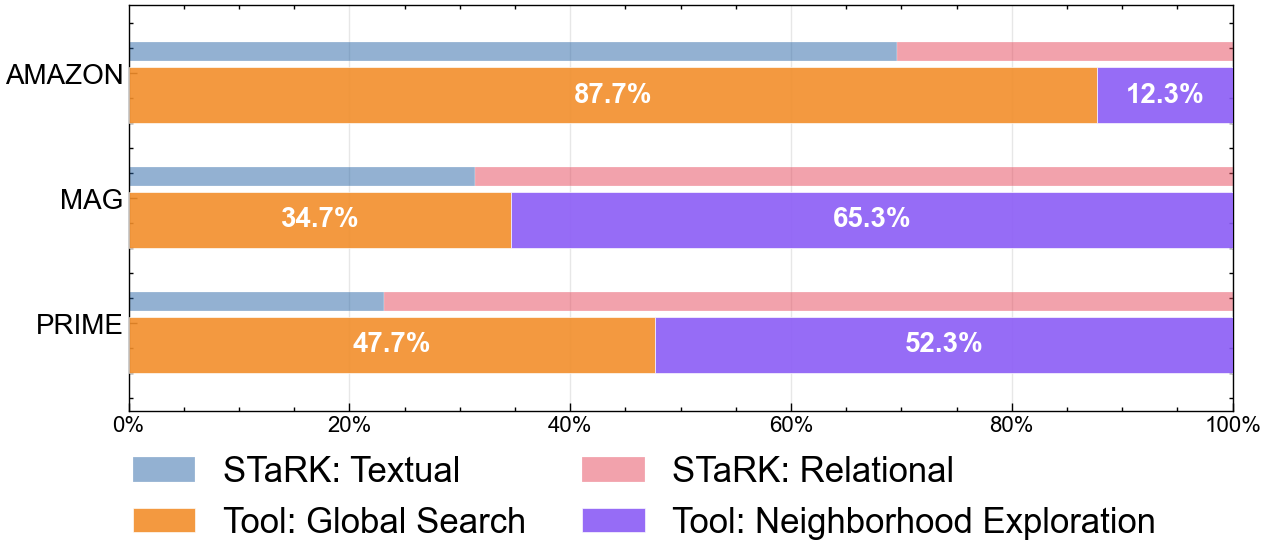

In [22]:

# ---- Font size and style constants ----
Y_LABEL_FONT_SIZE = 0
Y_TICKLABEL_FONT_SIZE = 20
VALUE_LABEL_FONT_SIZE = 20  # For numbers in bars
LEGEND_FONT_SIZE = 25       # Desired legend size (see below)
FONT_ARIAL = "Arial"


def calculate_search_tool_proportions(df):
    """Calculate proportions of search_in_graph vs search_in_neighborhood tool calls.
    
    Args:
        df: DataFrame with tool call count columns
        
    Returns:
        DataFrame with added columns: total_search_calls, prop_search_in_graph, 
        prop_search_in_neighborhood
    """
    search_in_graph_col = "number_of_tool_calls_search_in_graph"
    search_in_neighborhood_col = "number_of_tool_calls_search_in_neighborhood"
    
    df = df.copy()
    
    # Calculate total search tool calls
    df["total_search_calls"] = (
        df[search_in_graph_col].fillna(0) + 
        df[search_in_neighborhood_col].fillna(0)
    )
    
    # Calculate proportions (avoid division by zero)
    df["prop_search_in_graph"] = np.where(
        df["total_search_calls"] > 0,
        df[search_in_graph_col].fillna(0) / df["total_search_calls"],
        0
    )
    df["prop_search_in_neighborhood"] = np.where(
        df["total_search_calls"] > 0,
        df[search_in_neighborhood_col].fillna(0) / df["total_search_calls"],
        0
    )
    
    return df


def compute_mean_proportions(data_dict):
    """Compute mean tool call proportions for each graph.
    
    Args:
        data_dict: Dictionary mapping graph names to DataFrames with proportion columns
        
    Returns:
        Dictionary mapping graph names to mean proportions and trajectory counts
    """
    proportions = {}
    for graph_name, df in data_dict.items():
        proportions[graph_name] = {
            "search_in_graph": df["prop_search_in_graph"].mean(),
            "search_in_neighborhood": df["prop_search_in_neighborhood"].mean(),
            "n_trajectories": len(df)
        }
    return proportions


# Configuration: graphs to include in proportion analysis
proportion_graph_names = ['amazon', 'mag', 'prime']

# Load data for all graphs (including Amazon if not already loaded)
proportion_data = all_data.copy()
for graph_name in proportion_graph_names:
    if graph_name not in proportion_data:
        df = load_trajectory_data(graph_name, model_name, split)
        proportion_data[graph_name] = df
        print(f"Loaded {graph_name.upper()}: {df.shape[0]} samples")

# Calculate proportions for all trajectories (no filtering by success)
for graph_name in proportion_graph_names:
    proportion_data[graph_name] = calculate_search_tool_proportions(proportion_data[graph_name])

# Compute mean proportions
graph_proportions = compute_mean_proportions(proportion_data)

def plot_tool_proportions_comparison(
    graph_proportions,
    stark_proportions,
    graph_names,
    figsize=(12, 7),  # <---- Increased height from 5 to 7
):
    # Plotting constants
    BAR_HEIGHT_TOOL = 0.45
    BAR_HEIGHT_STARK = 0.15
    GAP = 0.05

    # Colors
    COLOR_STARK_TEXTUAL     = "#2865a6"   # blue
    COLOR_STARK_RELATIONAL  = "#e6475a"   # soft pink (less "red" than before)

    COLOR_TOOL_GRAPH        = "#F28E2B"   # orange
    COLOR_TOOL_NEIGHBORHOOD = "#8B5CF6"   # purple (less neon than #8338EC)
    # Prepare data
    y = np.arange(len(graph_names))
    offset_tool = 0.0
    offset_stark = -(BAR_HEIGHT_TOOL / 2 + GAP + BAR_HEIGHT_STARK / 2)

    tool_graph_means = [graph_proportions[g]["search_in_graph"] for g in graph_names]
    tool_neighbor_means = [graph_proportions[g]["search_in_neighborhood"] for g in graph_names]
    stark_textual_means = [stark_proportions[g]["textual"] for g in graph_names]
    stark_relational_means = [stark_proportions[g]["relational"] for g in graph_names]

    # Create figure + manually placed axes (full control)
    fig = plt.figure(figsize=figsize, constrained_layout=False)
    ax = fig.add_axes([0.07, 0.12, 0.92, 0.58])  # lower bottom, smaller height
    # --- STaRK bars (thin) ---
    ax.barh(
        y + offset_stark,
        stark_textual_means,
        height=BAR_HEIGHT_STARK,
        label="STaRK: Textual",
        color=COLOR_STARK_TEXTUAL,
        alpha=0.5,
        linewidth=0.3,
        edgecolor=(1.0, 1.0, 1.0, 0.4),
        zorder=2,
    )
    ax.barh(
        y + offset_stark,
        stark_relational_means,
        height=BAR_HEIGHT_STARK,
        left=stark_textual_means,
        label="STaRK: Relational",
        color=COLOR_STARK_RELATIONAL,
        alpha=0.5,
        linewidth=0.3,
        edgecolor=(1.0, 1.0, 1.0, 0.4),
        zorder=2,
    )

    # --- Tool bars (wide) ---
    ax.barh(
        y + offset_tool,
        tool_graph_means,
        height=BAR_HEIGHT_TOOL,
        label="Tool: Global Search",
        color=COLOR_TOOL_GRAPH,
        alpha=0.9,
        linewidth=0.5,
        edgecolor="white",
        zorder=3,
    )
    ax.barh(
        y + offset_tool,
        tool_neighbor_means,
        height=BAR_HEIGHT_TOOL,
        left=tool_graph_means,
        label="Tool: Neighborhood Exploration",
        color=COLOR_TOOL_NEIGHBORHOOD,
        alpha=0.9,
        linewidth=0.5,
        edgecolor="white",
        zorder=3,
    )

    # Value labels on tool bars (place *inside* the colored bar, white, matching the reference image)
    for i, (g_mean, n_mean) in enumerate(zip(tool_graph_means, tool_neighbor_means)):
        if g_mean > 0.05:
            ax.text(
                g_mean / 2,
                y[i] + offset_tool,
                f"{g_mean:.1%}",
                ha="center",
                va="center",
                fontweight="bold",
                color="white",
                fontsize=VALUE_LABEL_FONT_SIZE,
                fontname=FONT_ARIAL,
                zorder=4,
            )
        if n_mean > 0.05:
            ax.text(
                g_mean + n_mean / 2,
                y[i] + offset_tool,
                f"{n_mean:.1%}",
                ha="center",
                va="center",
                fontweight="bold",
                color="white",
                fontsize=VALUE_LABEL_FONT_SIZE,
                fontname=FONT_ARIAL,
                zorder=4,
            )

    # --- Axes formatting ---
    y_center = y + (offset_stark + offset_tool) / 2
    ax.set_yticks(y_center)
    ax.set_yticklabels([g.upper() for g in graph_names], fontsize=Y_TICKLABEL_FONT_SIZE, fontname=FONT_ARIAL)

    ax.set_xlim(0, 1.0)
    ax.margins(x=0)

    y_min = y.min() + offset_stark - BAR_HEIGHT_STARK / 2 - 0.30
    y_max = y.max() + offset_tool + BAR_HEIGHT_TOOL / 2 + 0.30
    ax.set_ylim(y_min, y_max)
    ax.invert_yaxis()

    ax.grid(True, alpha=0.3, axis="x", zorder=1)
    ax.set_axisbelow(True)
    ax.tick_params(top=False, right=False)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "{:.0%}".format(x)))

    # Set labels with Arial font
    # ax.set_xlabel(
    #     "Proportion of Tool Calls",
    #     fontsize=Y_LABEL_FONT_SIZE,
    #     fontname=FONT_ARIAL
    # )
    ax.set_ylabel(
        "",
        fontsize=Y_LABEL_FONT_SIZE,
        fontname=FONT_ARIAL
    )

    

    handles, labels = ax.get_legend_handles_labels()

    # Desired order for row-wise filling:
    # Row 1: STaRK Textual | STaRK Relational
    # Row 2: Tool Global   | Tool Neighborhood
    order = [0, 2, 1, 3]

    handles = [handles[i] for i in order]
    labels  = [labels[i]  for i in order]

    from matplotlib.font_manager import FontProperties
    legend_fp = FontProperties(family=FONT_ARIAL, size=LEGEND_FONT_SIZE)

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.1),
        ncol=2,                 # 2 columns → 2 rows
        framealpha=0.9,
        handlelength=1.8,
        columnspacing=1.6,
        prop={"family": FONT_ARIAL, "size": LEGEND_FONT_SIZE},
    )

    return fig

# STaRK paper proportions (from pixel measurements of STaRK paper Fig. 5)
STARK_PAPER_PROPORTIONS = {
    'amazon': {'textual': 0.696, 'relational': 0.304},
    'mag': {'textual': 0.314, 'relational': 0.686},
    'prime': {'textual': 0.231, 'relational': 0.769}
}

# Create and save proportion comparison plot
fig = plot_tool_proportions_comparison(
    graph_proportions, 
    STARK_PAPER_PROPORTIONS, 
    proportion_graph_names
)

filename = "fig-3-tool_call_proportions.pdf"
filepath = figures_dir / filename
fig.savefig(filepath, dpi=300, bbox_inches="tight", pad_inches=0.1)
print(f"Saved: {filepath}")

# Print summary statistics
print("\nTool Call Proportions (All Trajectories):")
print("=" * 60)
for graph_name in proportion_graph_names:
    props = graph_proportions[graph_name]
    print(f"\n{graph_name.upper()}:")
    print(f"  Search in Graph: {props['search_in_graph']:.2%}")
    print(f"  Search in Neighborhood: {props['search_in_neighborhood']:.2%}")
    print(f"  Total trajectories: {props['n_trajectories']}")

plt.show()

In [23]:
# ============================================================
# Analysis: How often is "Global Search" the first action
#            after the user emits the query?
# ============================================================


def get_first_tool_call(message_history):
    """Get the name of the first tool called in a trajectory's message history.

    Iterates through messages looking for the first assistant message
    that contains tool_calls, and returns the name of the first tool invoked.
    """
    for message in message_history:
        if message.get("role") == "assistant" and "tool_calls" in message:
            for tool_call in message["tool_calls"]:
                if "function" in tool_call and "name" in tool_call["function"]:
                    return tool_call["function"]["name"]
    return None


def analyze_first_tool_call(graph_name, model_name, split):
    """Analyze the first tool call in each trajectory for a given graph.

    Returns a list of tool names representing the first tool called
    in each trajectory.
    """
    data_dir = Path(f"../data/experiments/{graph_name}/{model_name}/{split}")
    log_files = sorted(data_dir.glob("*.json"), key=lambda f: f.stat().st_ctime)
    logs = [safe_open_json(f) for f in log_files]

    first_tool_calls = []
    for log in logs:
        if log is None:
            continue
        trajectory = log["trajectories"][0]
        message_history = trajectory["message_history"]
        first_tool = get_first_tool_call(message_history)
        first_tool_calls.append(first_tool)

    return first_tool_calls


print("=" * 60)
print("Analysis: How often is 'Global Search' the first action?")
print("=" * 60)

for graph_name in graph_names:
    first_calls = analyze_first_tool_call(graph_name, model_name, split)
    total = len(first_calls)
    global_search_first = sum(1 for t in first_calls if t == "search_in_graph")
    neighborhood_first = sum(1 for t in first_calls if t == "search_in_neighborhood")
    other_first = total - global_search_first - neighborhood_first

    pct_global = global_search_first / total * 100 if total > 0 else 0
    pct_neighborhood = neighborhood_first / total * 100 if total > 0 else 0

    print(f"\n{graph_name.upper()} ({total} trajectories):")
    print(f"  Global Search first:       {global_search_first:>5} ({pct_global:.1f}%)")
    print(f"  Neighborhood Search first: {neighborhood_first:>5} ({pct_neighborhood:.1f}%)")
    if other_first > 0:
        print(f"  Other first:               {other_first:>5} ({other_first/total*100:.1f}%)")

Analysis: How often is 'Global Search' the first action?

MAG (2501 trajectories):
  Global Search first:        2501 (100.0%)
  Neighborhood Search first:     0 (0.0%)

PRIME (2662 trajectories):
  Global Search first:        2662 (100.0%)
  Neighborhood Search first:     0 (0.0%)

AMAZON (1632 trajectories):
  Global Search first:        1632 (100.0%)
  Neighborhood Search first:     0 (0.0%)


In [24]:
# ============================================================
# Analysis: What percentage of trajectories only use one tool?
#            (All trajectories & successful only)
# ============================================================

SEARCH_GRAPH_COL = "number_of_tool_calls_search_in_graph"
SEARCH_NEIGHBORHOOD_COL = "number_of_tool_calls_search_in_neighborhood"


def print_tool_type_breakdown(subset, label, total):
    """Print a breakdown of tool-type usage for a subset of trajectories."""
    only_global = subset[
        (subset[SEARCH_GRAPH_COL] > 0) & (subset[SEARCH_NEIGHBORHOOD_COL] == 0)
    ]
    only_neighborhood = subset[
        (subset[SEARCH_GRAPH_COL] == 0) & (subset[SEARCH_NEIGHBORHOOD_COL] > 0)
    ]
    used_both = subset[
        (subset[SEARCH_GRAPH_COL] > 0) & (subset[SEARCH_NEIGHBORHOOD_COL] > 0)
    ]

    n_only_one = len(only_global) + len(only_neighborhood)
    pct = lambda n: f"{n / total * 100:.1f}%" if total > 0 else "0.0%"

    print(f"  {label} ({total} trajectories):")
    print(f"    Only Global Search:       {len(only_global):>5} ({pct(len(only_global))})")
    print(f"    Only Neighborhood Search: {len(only_neighborhood):>5} ({pct(len(only_neighborhood))})")
    print(f"    Used both tools:          {len(used_both):>5} ({pct(len(used_both))})")
    print(f"    ─────────────────────────────────────")
    print(f"    Only one tool type total: {n_only_one:>5} ({pct(n_only_one)})")


print("=" * 60)
print("Analysis: Trajectories using only one tool type")
print("=" * 60)

for graph_name in graph_names:
    df = all_data[graph_name]
    successful = df[df["hit_at_5"] == True]

    print(f"\n{graph_name.upper()}:")
    print_tool_type_breakdown(df, "All", len(df))
    print()
    print_tool_type_breakdown(successful, "Successful (Hit@5)", len(successful))

Analysis: Trajectories using only one tool type

MAG:
  All (2501 trajectories):
    Only Global Search:         372 (14.9%)
    Only Neighborhood Search:     0 (0.0%)
    Used both tools:           2129 (85.1%)
    ─────────────────────────────────────
    Only one tool type total:   372 (14.9%)

  Successful (Hit@5) (2063 trajectories):
    Only Global Search:         275 (13.3%)
    Only Neighborhood Search:     0 (0.0%)
    Used both tools:           1788 (86.7%)
    ─────────────────────────────────────
    Only one tool type total:   275 (13.3%)

PRIME:
  All (2662 trajectories):
    Only Global Search:         777 (29.2%)
    Only Neighborhood Search:     0 (0.0%)
    Used both tools:           1885 (70.8%)
    ─────────────────────────────────────
    Only one tool type total:   777 (29.2%)

  Successful (Hit@5) (1650 trajectories):
    Only Global Search:         402 (24.4%)
    Only Neighborhood Search:     0 (0.0%)
    Used both tools:           1248 (75.6%)
    ────────────

In [25]:
# ============================================================
# Analysis: % of trajectories where Global Search is used
#            after the first step (All & Successful only)
# ============================================================

def get_tool_call_sequence(message_history):
    """Extract the ordered sequence of tool calls from a trajectory."""
    sequence = []
    for message in message_history:
        if message.get("role") == "assistant" and "tool_calls" in message:
            for tool_call in message["tool_calls"]:
                if "function" in tool_call and "name" in tool_call["function"]:
                    sequence.append(tool_call["function"]["name"])
    return sequence


def analyze_global_search_after_first_step(graph_name, model_name, split):
    """For each trajectory, check whether search_in_graph appears after the first tool call.

    Also tracks hit@5 so results can be split by success.

    Returns a list of dicts with keys: 'global_after_first' (bool), 'hit_at_5' (bool).
    """
    data_dir = Path(f"../data/experiments/{graph_name}/{model_name}/{split}")
    log_files = sorted(data_dir.glob("*.json"), key=lambda f: f.stat().st_ctime)
    logs = [safe_open_json(f) for f in log_files]

    rows = []
    for log in logs:
        if log is None:
            continue
        trajectory = log["trajectories"][0]
        seq = get_tool_call_sequence(trajectory["message_history"])
        if not seq:
            continue

        retrieved = trajectory["agent_answer_indices"]
        gt = set(log["answer_indices"])
        hit_at_5 = bool(set(retrieved[:5]).intersection(gt))

        rows.append({
            "global_after_first": "search_in_graph" in seq[1:],
            "hit_at_5": hit_at_5,
        })

    return rows


def print_global_after_first_breakdown(rows, label, total):
    count = sum(1 for r in rows if r["global_after_first"])
    pct = f"{count / total * 100:.1f}%" if total > 0 else "0.0%"
    print(f"  {label} ({total} trajectories):")
    print(f"    Global Search after 1st step: {count:>5} ({pct})")


print("=" * 65)
print("Analysis: Global Search used after the first step")
print("=" * 65)

for graph_name in graph_names:
    rows = analyze_global_search_after_first_step(graph_name, model_name, split)
    successful = [r for r in rows if r["hit_at_5"]]

    print(f"\n{graph_name.upper()}:")
    print_global_after_first_breakdown(rows, "All", len(rows))
    print()
    print_global_after_first_breakdown(successful, "Successful (Hit@5)", len(successful))

Analysis: Global Search used after the first step

MAG:
  All (2501 trajectories):
    Global Search after 1st step:   631 (25.2%)

  Successful (Hit@5) (2063 trajectories):
    Global Search after 1st step:   422 (20.5%)

PRIME:
  All (2662 trajectories):
    Global Search after 1st step:   981 (36.9%)

  Successful (Hit@5) (1650 trajectories):
    Global Search after 1st step:   590 (35.8%)

AMAZON:
  All (1632 trajectories):
    Global Search after 1st step:   165 (10.1%)

  Successful (Hit@5) (1206 trajectories):
    Global Search after 1st step:   107 (8.9%)
